# Chapter 5 - Linear Models and Regularization

Reproduksi pembelajaran **scikit-learn Cookbook, Third Edition**, John Sukup (Packt, 2025), untuk mata kuliah Pembelajaran Mesin.

Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_5) beserta exercise solutions. Teori dan interpretasi disusun dalam bahasa Indonesia. Perubahan penting dijelaskan di README. Dataset sintetis diberi label, output disimpan, dan seluruh notebook dapat dijalankan ulang dari kernel baru.

## Daftar Isi

- [Introduction to Linear Models](#introduction-to-linear-models)
- [Ridge and Lasso Regression](#ridge-and-lasso-regression)
- [ElasticNet and Regularization](#elasticnet-and-regularization)
- [Polynomial Regression](#polynomial-regression)
- [Spline Regression](#spline-regression)
- [Practical Exercises with Linear Models and Regularization](#practical-exercises-with-linear-models-and-regularization)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.utils import Bunch

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})

## Introduction to Linear Models

Regresi linear memodelkan $\hat y=\beta_0+\sum_j\beta_j x_j$ dengan least squares. Koefisien menggambarkan asosiasi kondisional pada fitur lain; bukan efek kausal otomatis. Multikolinearitas dapat membuat koefisien tidak stabil walaupun prediksi cukup baik. Contoh memakai 1.000 sampel sintetis, 100 fitur, noise, dan fitur berkorelasi.

MSE adalah rata-rata kuadrat error; RMSE mempunyai satuan target. $R^2=1-SSE/SST$ membandingkan dengan prediksi mean pada data evaluasi dan dapat negatif. Nilai training tidak cukup untuk menilai generalisasi. Garis terhadap feature_0 pada plot merupakan potongan model dengan 99 fitur lain nol, bukan fit regresi satu variabel.

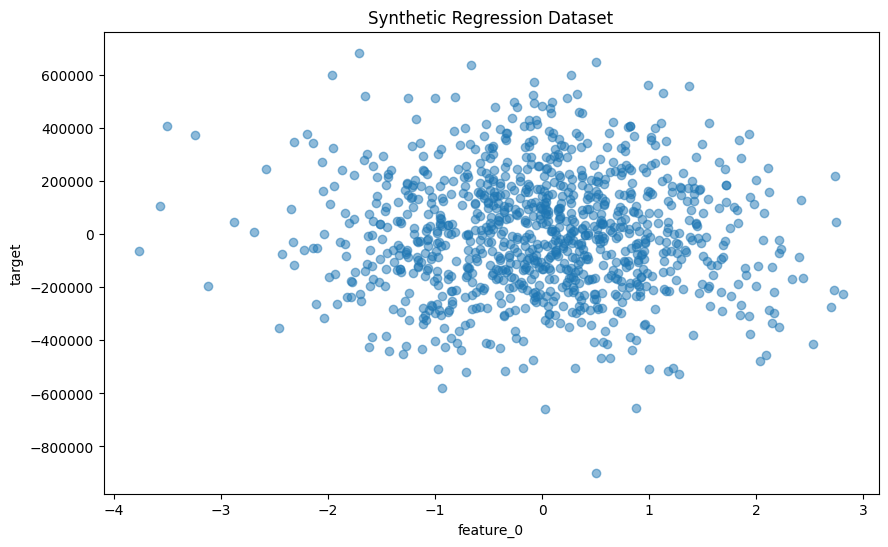

In [2]:
# Load libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# Create synthetic regression dataset with high multicollinearity and more features
X, y = make_regression(n_samples=1000,
                      n_features=100,     
                      n_informative=10,   
                      noise=20,           
                      random_state=123)

# Add multicollinearity by creating correlated features
for i in range(50, 100):  # Make half the features correlated
    X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

# Create feature names
feature_names = [f'feature_{i}' for i in range(100)]

# Take just the first feature for visualization
X_plot = X[:, 0].reshape(-1, 1)

# Add some non-linearity and make coefficients vary widely in magnitude
y = y * 1000  # Scale up the target
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel()/10)

# Convert to pandas DataFrame with feature names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df_plot = pd.DataFrame({'feature_0': X_plot.ravel(), 'target': y})

# Quick visualization of the data
plt.figure(figsize=(10, 6))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Synthetic Regression Dataset')
plt.show()

Mean Squared Error: 43406762489.12
R-squared: 0.13


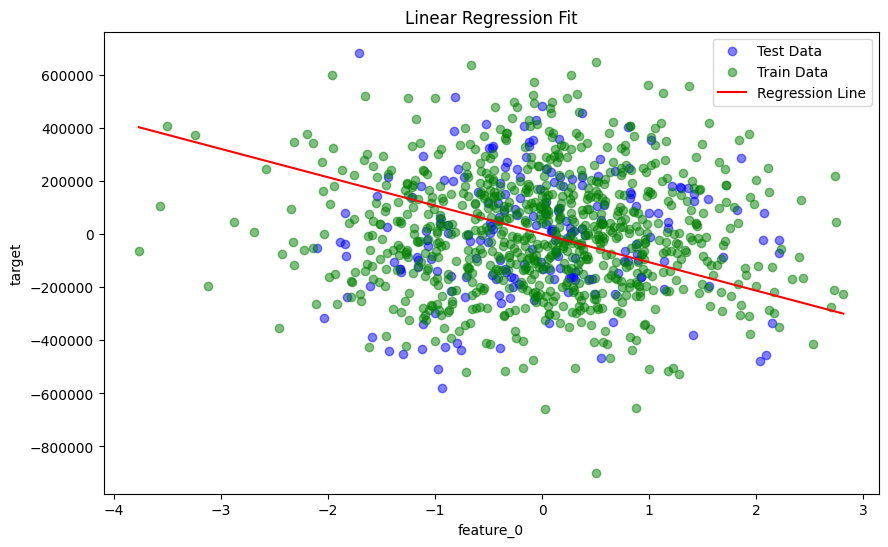

In [3]:
# Load libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate performance using MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

# Visualize the data and regression line (using feature_0 for visualization)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.5, label='Train Data')

# Sort the data for a smooth line plot
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()  # Set feature_0, leave others as 0
y_line = linear_model.predict(X_line_full)

plt.plot(X_line, y_line, color='red', label='Regression Line')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

initial_linear_mse = mse

## Ridge and Lasso Regression

Ridge menambah penalti L2 yang menyusutkan koefisien dan membantu multikolinearitas, tetapi biasanya tidak membuatnya tepat nol. Lasso memakai L1 sehingga sebagian koefisien bisa nol; fitur berkorelasi dapat dipilih secara tidak stabil. Alpha mengatur kekuatan penalti dan perlu dipilih pada validation. Skala fitur memengaruhi penalti, sehingga scaling umumnya dilakukan di dalam pipeline.

Contoh awal memakai fitur sintetis dengan skala hampir sama untuk mengikuti buku. Ridge, Lasso, dan OLS dibandingkan pada split sama; regularisasi tidak otomatis menghasilkan MSE lebih rendah untuk semua data atau setiap alpha.

,Model,Mean Squared Error,R-squared
0,Ridge Regression,42930147665.94,0.14
1,Lasso Regression,43352039348.94,0.13
2,Linear Regression,43406762489.12,0.13


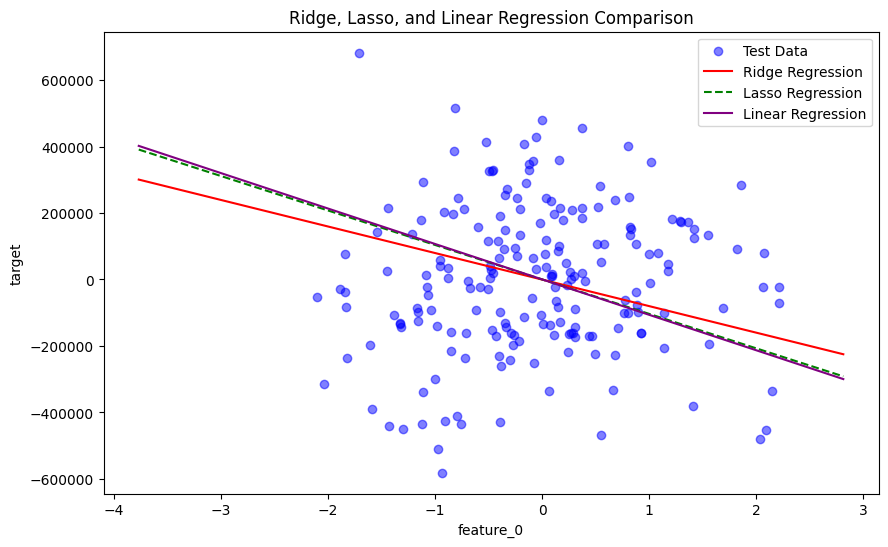

In [4]:
# Load libraries
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Create and fit Ridge regression model
ridge_model = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge_model.fit(X_train, y_train)

# Create and fit Lasso regression model with increased iterations and alpha
lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

# Make predictions with both models
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate performance
y_pred_linear = linear_model.predict(X_test)

# Calculate metrics for all models
metrics = {
    'Model': ['Ridge Regression', 'Lasso Regression', 'Linear Regression'],
    'Mean Squared Error': [
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_linear)
    ],
    'R-squared': [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso), 
        r2_score(y_test, y_pred_linear)
    ]
}

# Create DataFrame and sort by MSE
metrics_df = pd.DataFrame(metrics)
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format the numeric columns
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

display(metrics_df)

# Visualize the results (using feature_0 for visualization)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.5, label='Test Data')

# Sort the data for smooth line plots
X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
X_line_df = X_line_full

# Generate predictions for the line
y_line_ridge = ridge_model.predict(X_line_df)
y_line_lasso = lasso_model.predict(X_line_df)
y_line_linear = linear_model.predict(X_line_df)

plt.plot(X_line, y_line_ridge, color='red', label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green', linestyle='--', label='Lasso Regression')
plt.plot(X_line, y_line_linear, color='purple', label='Linear Regression')
plt.xlabel('feature_0')
plt.ylabel('target')
plt.title('Ridge, Lasso, and Linear Regression Comparison')
plt.legend()
plt.show()

## ElasticNet and Regularization

ElasticNet meminimalkan $\|y-Xw\|^2/(2n)+\alpha r\|w\|_1+\alpha(1-r)\|w\|^2/2$. `l1_ratio=r` menggabungkan sparsity L1 dan shrinkage L2. Pada scikit-learn, normalisasi fungsi objektif Ridge berbeda dari Lasso/ElasticNet, sehingga alpha numerik sama tidak berarti kekuatan penalti yang identik.

Coefficient path memperlihatkan perubahan parameter ketika alpha meningkat; bukan confidence interval. Regularisasi menambah bias untuk mengendalikan variance. Nilai alpha terlalu besar dapat underfit. Pemilihan model mempertimbangkan validation error, kestabilan koefisien, sparsity, dan tujuan interpretasi.

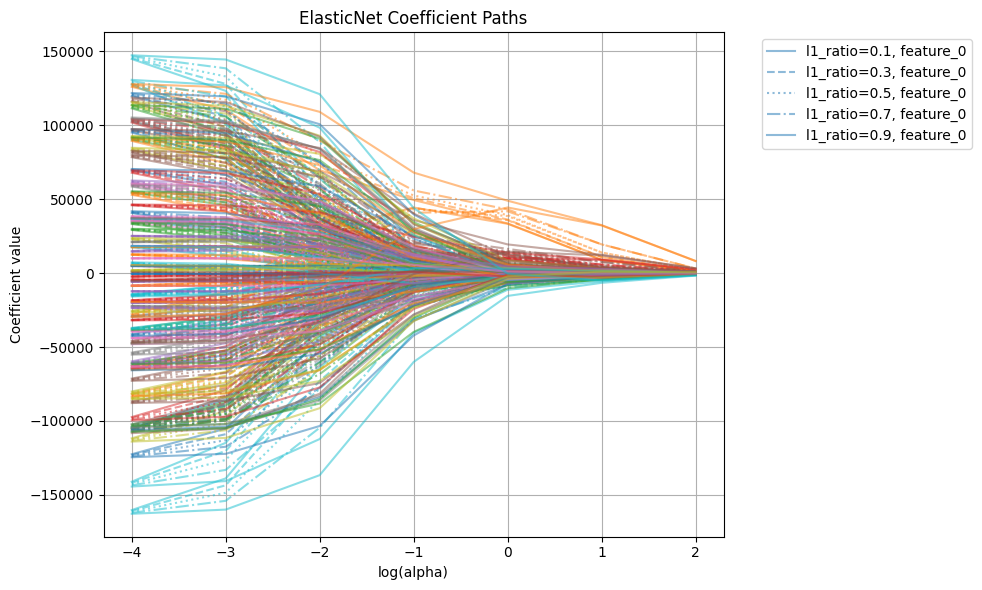

,Model,Mean Squared Error,R-squared
3,ElasticNet Regression,42634873340.85,0.14
0,Ridge Regression,42930147665.94,0.14
1,Lasso Regression,43352039348.94,0.13
2,Linear Regression,43406762489.12,0.13


In [5]:
# Load libraries
from sklearn.linear_model import ElasticNet

# Create a range of alphas to test
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# Store coefficients for plotting
coef_paths = []
labels = []

# Create and fit ElasticNet models with different parameters
plt.figure(figsize=(10, 6))

for l1_ratio in l1_ratios:
    coefs = []
    for alpha in alphas:
        # Create and fit ElasticNet model with increased max_iter and tol
        elastic_model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=123,
                                 max_iter=10000, tol=1e-4)
        elastic_model.fit(X_train, y_train)
        coefs.append(elastic_model.coef_)

    # Convert coefficients to array and store
    coef_paths.append(np.array(coefs))

    # Plot coefficient paths
    for feature_idx in range(X_train.shape[1]):
        plt.plot(np.log10(alphas), 
                np.array(coefs)[:, feature_idx], 
                label=f'l1_ratio={l1_ratio}, feature_{feature_idx}' if feature_idx == 0 else "",
                alpha=0.5,
                linestyle=['solid', 'dashed', 'dotted', 'dashdot', '-'][l1_ratios.index(l1_ratio)])

plt.xlabel('log(alpha)')
plt.ylabel('Coefficient value')
plt.title('ElasticNet Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Create a model with balanced l1_ratio and moderate alpha
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=123,
                          max_iter=10000, tol=1e-4)  
elastic_model.fit(X_train, y_train)

# Calculate metrics
elastic_pred = elastic_model.predict(X_test)
elastic_mse = mean_squared_error(y_test, elastic_pred)
elastic_r2 = r2_score(y_test, elastic_pred)

# Add ElasticNet results to metrics DataFrame
new_row = pd.DataFrame({
    'Model': ['ElasticNet Regression'],
    'Mean Squared Error': [elastic_mse],
    'R-squared': [elastic_r2]
})

# Remove any existing ElasticNet entries before concatenating
metrics_df = metrics_df[~metrics_df['Model'].str.contains('ElasticNet')]

# Convert string values back to float for sorting
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].astype(float)
metrics_df['R-squared'] = metrics_df['R-squared'].astype(float)

metrics_df = pd.concat([metrics_df, new_row], ignore_index=True)

# Sort the metrics DataFrame by Mean Squared Error
metrics_df = metrics_df.sort_values('Mean Squared Error', ascending=True)

# Format the numeric columns for display
metrics_df['Mean Squared Error'] = metrics_df['Mean Squared Error'].map('{:.2f}'.format)
metrics_df['R-squared'] = metrics_df['R-squared'].map('{:.2f}'.format)

# Display updated metrics
display(metrics_df)

## Polynomial Regression

PolynomialFeatures menambah $x^2,x^3,\ldots$ sehingga bentuk terhadap x nonlinier meskipun model tetap linear terhadap koefisien. Derajat tinggi dapat memperbesar variance dan membuat ekstrapolasi tidak stabil. Derajat pada reproduksi dipilih melalui CV training; test dipakai setelah pemilihan, bukan untuk memilih derajat terbaik.

Kurva ditampilkan dari model yang fit pada training. Pola residual membantu memeriksa bentuk mean dan perubahan variasi error, tetapi satu grafik tidak membuktikan seluruh asumsi regresi.

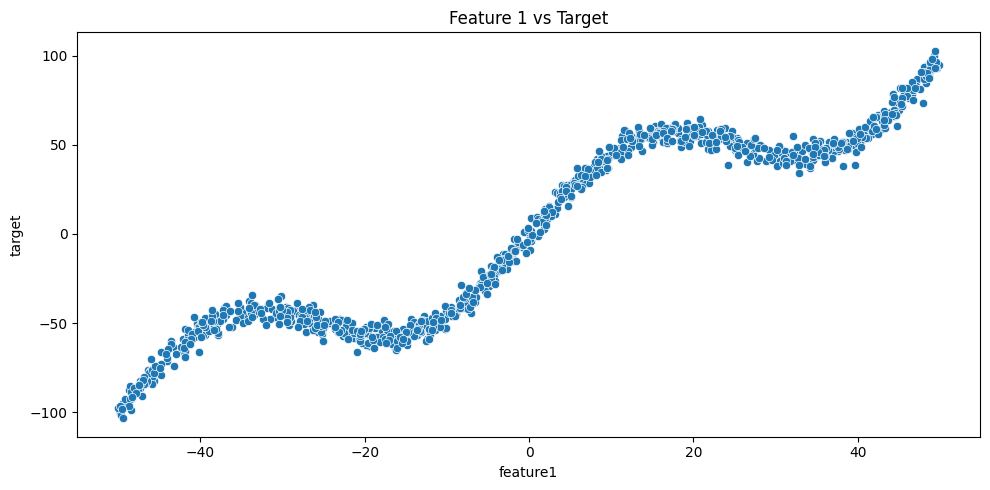

In [6]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create synthetic dataset with non-linear relationships
np.random.seed(123)
n_samples = 1000
X = np.random.uniform(-50, 50, (n_samples, 1))

# Create target with non-linear components:
y = (2 * X[:, 0]  # linear component
     + 27 * np.sin(X[:, 0] / 8)  
     + np.random.normal(0, 4, n_samples))  # noise

# Create DataFrame
data = pd.DataFrame(X, columns=['feature1'])
data['target'] = y

# Create plot
plt.figure(figsize=(10, 5))
sns.scatterplot(data=data, x='feature1', y='target')
plt.title('Feature 1 vs Target')
plt.tight_layout()
plt.show()

,Degree,CV_MSE
0,1,343.044633
1,2,343.453493
2,3,279.105785
3,4,279.503576
4,5,48.028990


CV-selected degree: 5
Test MSE: 48.31616723928059 Test R2: 0.9834073839598844


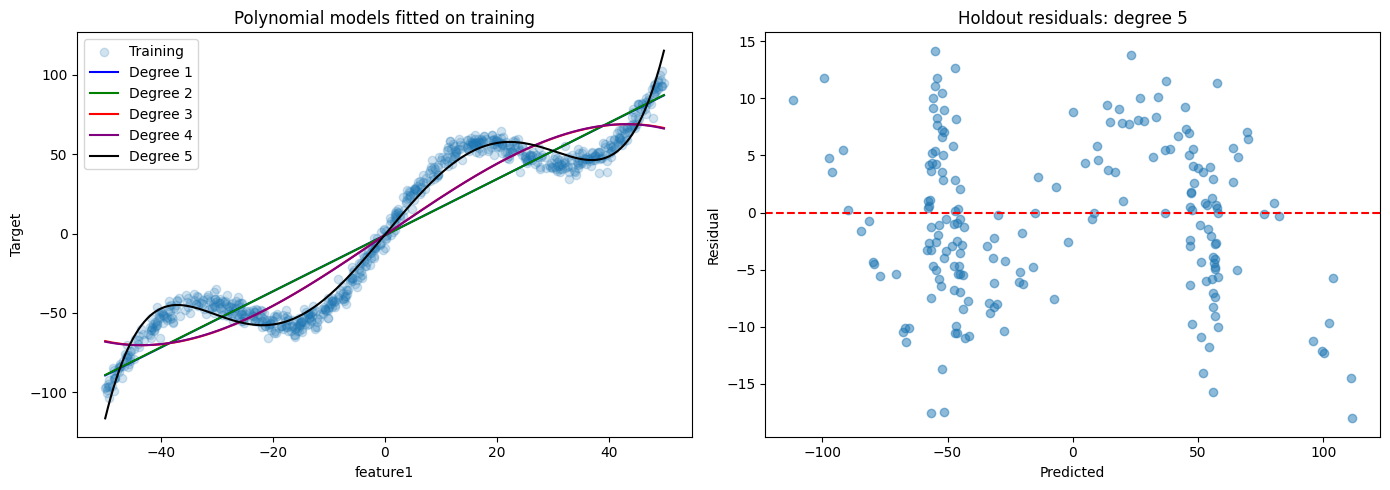

In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
X = data[['feature1']]
y = data['target']
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X, y, test_size=0.2, random_state=123)
poly_search = GridSearchCV(Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()), ('regressor', LinearRegression())
]), {'poly__degree': [1, 2, 3, 4, 5]}, cv=5,
    scoring='neg_mean_squared_error', error_score='raise')
poly_search.fit(X_train_poly, y_train_poly)
best_degree = poly_search.best_params_['poly__degree']
poly_best = poly_search.best_estimator_
y_pred_poly = poly_best.predict(X_test_poly)
poly_test_mse = mean_squared_error(y_test_poly, y_pred_poly)
poly_test_r2 = r2_score(y_test_poly, y_pred_poly)
display(pd.DataFrame({'Degree': [p['poly__degree'] for p in poly_search.cv_results_['params']],
    'CV_MSE': -poly_search.cv_results_['mean_test_score']}))
print('CV-selected degree:', best_degree)
print('Test MSE:', poly_test_mse, 'Test R2:', poly_test_r2)
X_plot = pd.DataFrame({'feature1': np.linspace(X_train_poly.feature1.min(), X_train_poly.feature1.max(), 400)})
colors = ['blue', 'green', 'red', 'purple', 'black']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_train_poly.feature1, y_train_poly, alpha=0.2, label='Training')
for degree, color in zip([1, 2, 3, 4, 5], colors):
    candidate = Pipeline([('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                          ('scaler', StandardScaler()), ('regressor', LinearRegression())])
    candidate.fit(X_train_poly, y_train_poly)
    axes[0].plot(X_plot.feature1, candidate.predict(X_plot), color=color, label=f'Degree {degree}')
axes[0].set(xlabel='feature1', ylabel='Target', title='Polynomial models fitted on training')
axes[0].legend()
axes[1].scatter(y_pred_poly, y_test_poly-y_pred_poly, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set(xlabel='Predicted', ylabel='Residual', title=f'Holdout residuals: degree {best_degree}')
plt.tight_layout(); plt.show()

## Spline Regression

SplineTransformer membangun basis B-spline berupa polinomial lokal yang tersambung di knot. Bersama LinearRegression, ini adalah regresi spline, bukan interpolasi yang wajib melewati setiap titik. Jumlah knot mengatur fleksibilitas. Knot dipelajari pada training melalui pipeline dan hasil dibedakan antara error training dan test. Perbandingan beberapa konfigurasi test bersifat ilustratif; konfigurasi final untuk deployment memerlukan pemilihan pada validation.

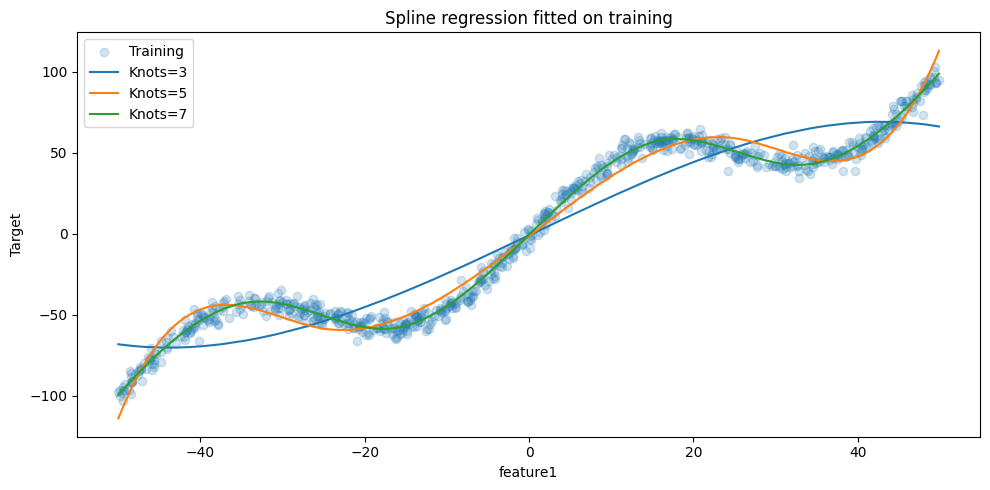

,Knots,Train_MSE,Test_MSE,Test_R2
0,3,276.040049,267.979081,0.907971
1,5,55.174352,57.007946,0.980422
2,7,15.380241,16.310116,0.994399


In [8]:
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
spline_scores = []
plt.figure(figsize=(10, 5))
plt.scatter(X_train_poly.feature1, y_train_poly, alpha=0.2, label='Training')
for knots in [3, 5, 7]:
    spline_model = make_pipeline(SplineTransformer(n_knots=knots, degree=3), LinearRegression())
    spline_model.fit(X_train_poly, y_train_poly)
    spline_scores.append({'Knots': knots,
        'Train_MSE': mean_squared_error(y_train_poly, spline_model.predict(X_train_poly)),
        'Test_MSE': mean_squared_error(y_test_poly, spline_model.predict(X_test_poly)),
        'Test_R2': r2_score(y_test_poly, spline_model.predict(X_test_poly))})
    plt.plot(X_plot.feature1, spline_model.predict(X_plot), label=f'Knots={knots}')
plt.legend(); plt.xlabel('feature1'); plt.ylabel('Target'); plt.title('Spline regression fitted on training')
plt.tight_layout(); plt.show()
display(pd.DataFrame(spline_scores))

## Practical Exercises with Linear Models and Regularization

Latihan Ridge, Lasso, dan ElasticNet memakai tiga dataset sintetis berbeda, sehingga skor antarlatihan tidak merupakan ranking algoritma. Ridge linear pada target kuadratik masih dapat underfit karena penalti tidak menambah bentuk kuadratik. Lasso dapat menyusutkan slope, dan ElasticNet menggabungkan dua penalti. Setiap latihan melaporkan MSE/R-squared training serta test dan menampilkan kurva prediksi.

### Latihan 1: Implementing Ridge Regression

Ridge linear dilatih pada target kuadratik dengan noise. MSE training/test membantu menunjukkan bahwa penalti saja tidak menambah komponen kuadratik.

Training Metrics:
MSE: 1.9780
R²: 0.6575

Test Metrics:
MSE: 2.5628
R²: -0.0360


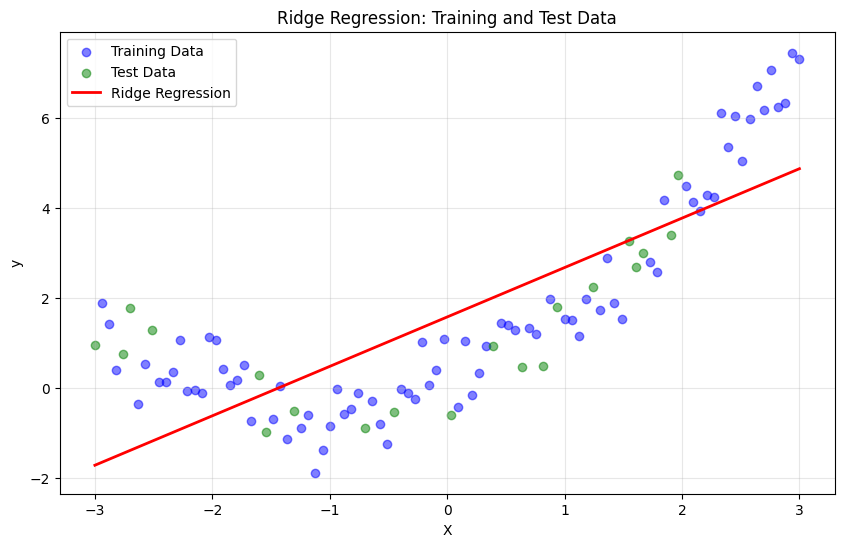

In [9]:
# Load libraries
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic dataset with some noise
np.random.seed(123)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 0.5 * X.ravel()**2 + X.ravel() + np.random.normal(0, 0.5, 100)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Ridge regression model
ridge = Ridge(alpha=1.0)  # alpha is the regularization strength
ridge.fit(X_train, y_train)

# Make predictions
y_pred_train = ridge.predict(X_train)
y_pred_test = ridge.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = ridge.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Ridge Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Ridge Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Latihan 2: Implementing Lasso Regression

Lasso dilatih pada data linear dengan noise. Prediksi training/test dan kurva memperlihatkan pengaruh shrinkage pada slope.

Training Metrics:
MSE: 0.2631
R²: 0.8814

Test Metrics:
MSE: 0.4239
R²: 0.8419


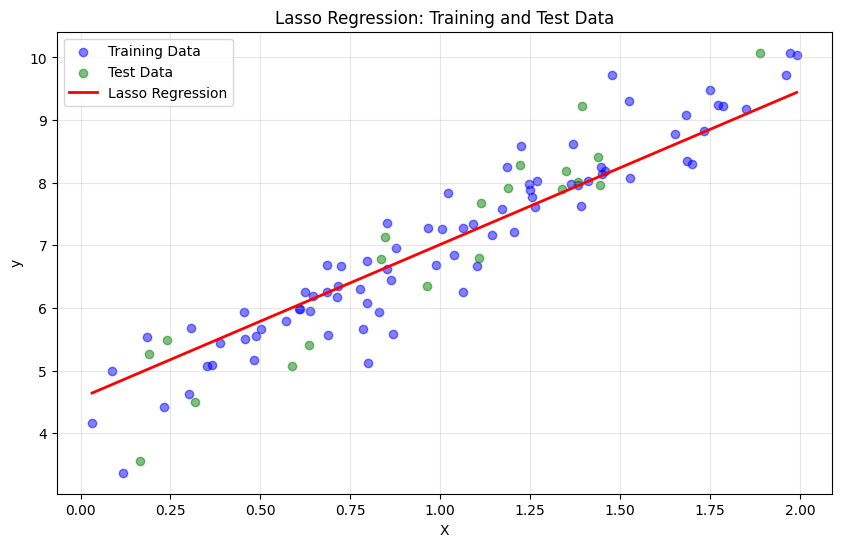

In [10]:
# Load libraries
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(123)
X = 2 * np.random.rand(100, 1)
y = (4 + 3 * X + np.random.randn(100, 1) * 0.5).ravel()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit Lasso regression model
lasso = Lasso(alpha=0.1)  # alpha is the regularization strength
lasso.fit(X_train, y_train)

# Make predictions
y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = lasso.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='Lasso Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Lasso Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

lasso_exercise_test_r2 = r2_test

### Latihan 3: Implementing ElasticNet Regression

ElasticNet dilatih pada respons linear ditambah komponen sinus dan noise. Alpha dan l1_ratio mengendalikan penalti, sementara skor hanya dibandingkan pada dataset latihan ini.

Training Metrics:
MSE: 4.6771
R²: 0.9849

Test Metrics:
MSE: 4.0393
R²: 0.9867


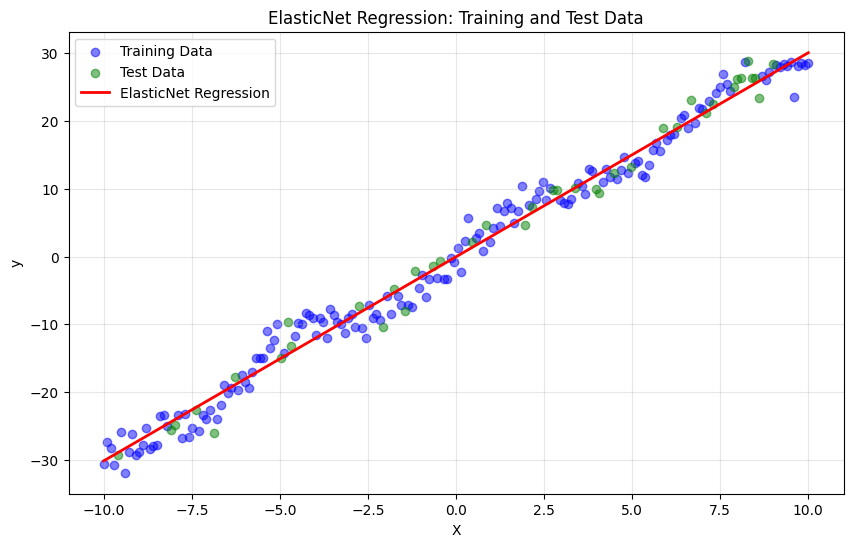

In [11]:
# Load libraries
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(123)
X = np.linspace(-10, 10, 200).reshape(-1, 1)
y = (3*X + np.sin(X) * 2 + np.random.normal(0, 1.5, X.shape)).ravel()

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Create and fit ElasticNet model
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # alpha is regularization strength, l1_ratio balances L1/L2
elastic_net.fit(X_train, y_train)

# Make predictions
y_pred_train = elastic_net.predict(X_train)
y_pred_test = elastic_net.predict(X_test)

# Calculate metrics
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print metrics
print("Training Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"R²: {r2_train:.4f}")
print("\nTest Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"R²: {r2_test:.4f}")

# Visualize results
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Training Data')
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')

# Sort X values for smooth line plot
X_plot = np.sort(X, axis=0)
y_plot = elastic_net.predict(X_plot)
plt.plot(X_plot, y_plot, color='red', linewidth=2, label='ElasticNet Regression')

plt.xlabel('X')
plt.ylabel('y')
plt.title('ElasticNet Regression: Training and Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Pemeriksaan Hasil

Angka berikut merangkum hasil eksekusi, disertai assertion untuk memeriksa konsistensi tertentu. Pemeriksaan kode tidak membuktikan asumsi statistik atau representativitas data.

In [12]:
chapter_results = {'synthetic_linear_mse': float(initial_linear_mse),
 'polynomial_degree_selected_by_cv': int(best_degree),
 'polynomial_test_mse': float(poly_test_mse),
 'polynomial_test_r2': float(poly_test_r2),
 'lasso_exercise_test_r2': float(lasso_exercise_test_r2)}
assert len(poly_best.predict(X_test_poly)) == len(y_test_poly)
assert np.isfinite(poly_test_mse)
print(json.dumps(chapter_results, indent=2))

{
  "synthetic_linear_mse": 43406762489.12417,
  "polynomial_degree_selected_by_cv": 5,
  "polynomial_test_mse": 48.31616723928059,
  "polynomial_test_r2": 0.9834073839598844,
  "lasso_exercise_test_r2": 0.8419382551821905
}


## Ringkasan Bab

OLS, Ridge, Lasso, dan ElasticNet membedakan fit tanpa penalti, shrinkage L2, sparsity L1, serta campuran keduanya. Nilai alpha perlu dinilai bersama skala fitur dan target; angka alpha yang sama tidak mempunyai kekuatan identik pada semua fungsi objektif scikit-learn. Coefficient path menggambarkan perubahan koefisien, bukan confidence interval.

Pada data nonlinier, CV training memilih **polynomial degree 5**, dengan **MSE test 48.316** dan **R-squared test 0.9834**. Derajat dipilih tanpa melihat skor test. Spline memberikan alternatif bentuk lokal dan tabelnya memisahkan MSE training/test. Latihan Lasso menghasilkan **R-squared test 0.8419**, tetapi latihannya memakai dataset berbeda dari Ridge dan ElasticNet sehingga hasil itu tidak menjadi ranking antarmetode. Regularisasi mengendalikan kompleksitas; ia tidak memperbaiki bentuk model yang salah dengan sendirinya.